# Konvolyutsion neyron tarmoq (CNN) — FashionMNIST

MLP rasmni 784 ta songa yoyib yuboradi va qaysi piksel qaysining yonida turgani yo'qoladi.
CNN esa kichik filtrni rasm ustida sirg'atadi va bitta filtrni butun rasm bo'ylab qayta ishlatadi —
shuning uchun parametrlar kamroq, natija yaxshiroq.

In [1]:
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision.datasets as datasets
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001

CONV1_CHANNELS = 32       # number of filters in the first conv layer
CONV2_CHANNELS = 64       # number of filters in the second conv layer
KERNEL1 = 5               # 5x5 filters are easier to read when we plot them at the end
KERNEL2 = 3
FC_HIDDEN = 128
DROPOUT = 0.3

torch.manual_seed(42)
generator = torch.Generator().manual_seed(42)

print('Device:', DEVICE)

Device: mps


## FashionMNIST

MNIST bilan bir xil format — 28x28 kulrang rasm, 10 ta sinf — lekin raqamlar o'rniga kiyim,
va vazifa qiyinroq. O'qitish to'plamidan 10% validatsiya uchun ajratiladi, testga faqat oxirida qaraymiz.

Train / Val / Test: 54000 / 6000 / 10000
Bitta batch: (128, 1, 28, 28)   # [batch, channels, height, width]
Piksel oralig'i: [0.0, 1.0]


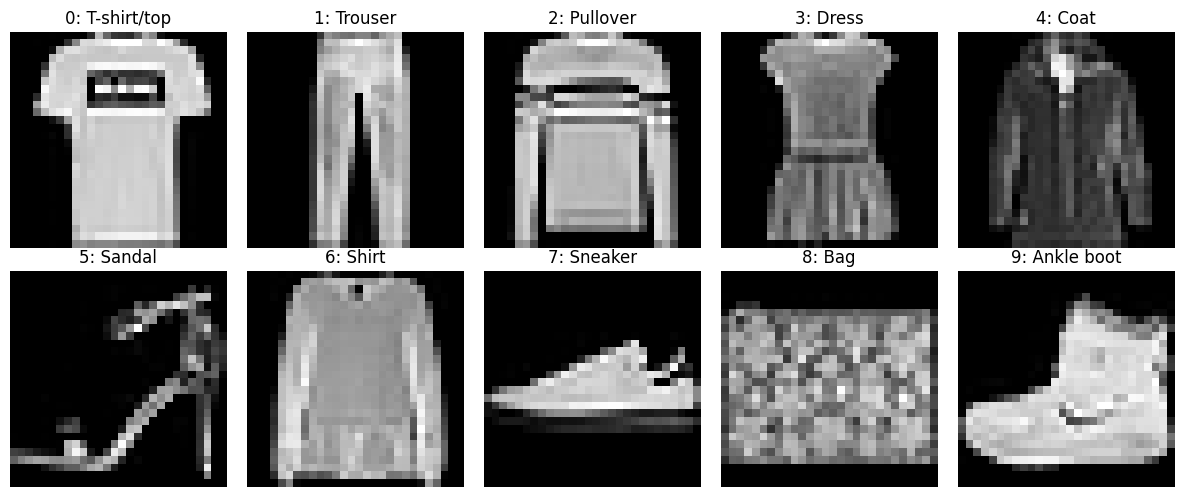

In [2]:
CLASSES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

train_full = datasets.FashionMNIST(root="./data", train=True,
                                   transform=transforms.ToTensor(), download=True)
test_dataset = datasets.FashionMNIST(root="./data", train=False,
                                     transform=transforms.ToTensor(), download=True)

val_size = len(train_full) // 10
train_dataset, val_dataset = random_split(
    train_full, [len(train_full) - val_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))

print("Train / Val / Test:", len(train_dataset), "/", len(val_dataset), "/", len(test_dataset))
print("Bitta batch:", tuple(x_batch.shape), "  # [batch, channels, height, width]")
print("Piksel oralig'i:", f"[{x_batch.min():.1f}, {x_batch.max():.1f}]")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_id, ax in enumerate(axes.flat):
    index = (train_full.targets == class_id).nonzero()[0].item()
    ax.imshow(train_full[index][0].squeeze(), cmap="gray")
    ax.set_title(f"{class_id}: {CLASSES[class_id]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Model

Klassik shablon, ikki marta takrorlanadi: `Conv -> BatchNorm -> ReLU -> MaxPool`.

`padding = kernel // 2` rasm o'lchamini o'zgarishsiz qoldiradi, `MaxPool2d(2, 2)` esa uni
ataylab 2 barobar kichraytiradi. Har bir blokda o'lcham kamayadi, kanallar soni esa ko'payadi:
bu "qayerda" dan "nima" ga o'tish. Oxirida `[64, 7, 7]` tensor yoyilib, oddiy `Linear`
qatlamlarga uzatiladi — ya'ni yoyish baribir bor, lekin konvolyutsiyalar ishini tugatgandan **keyin**.

In [ ]:
class CNN(nn.Module):
    def __init__(self, conv1_channels, conv2_channels, fc_hidden, dropout, num_classes=10):
        super().__init__()

        # [1, 28, 28] -> conv -> [32, 28, 28] -> pool -> [32, 14, 14]
        self.conv1 = nn.Conv2d(1, conv1_channels, kernel_size=KERNEL1, padding=KERNEL1 // 2)
        self.bn1 = nn.BatchNorm2d(conv1_channels)

        # [32, 14, 14] -> conv -> [64, 14, 14] -> pool -> [64, 7, 7]
        self.conv2 = nn.Conv2d(conv1_channels, conv2_channels, kernel_size=KERNEL2,
                               padding=KERNEL2 // 2)
        self.bn2 = nn.BatchNorm2d(conv2_channels)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(conv2_channels * 7 * 7, fc_hidden)   # 64 * 7 * 7 = 3136
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.flatten(start_dim=1)      # keep the batch dimension, flatten the rest

        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


model = CNN(CONV1_CHANNELS, CONV2_CHANNELS, FC_HIDDEN, DROPOUT).to(DEVICE)

print(model)
print("\nParametrlar soni:", f"{sum(p.numel() for p in model.parameters()):,}")

# walk one batch through the layers and watch the shape change
model.eval()
h = x_batch[:8].to(DEVICE)
with torch.no_grad():
    print(f"\n{'qadam':<16}{'shakl':<22}{'sonlar soni':>12}")
    print(f"{'kirish':<16}{str(tuple(h.shape)):<22}{h[0].numel():>12,}")
    for name, step in [
        ("conv1 blok", lambda t: model.pool(model.relu(model.bn1(model.conv1(t))))),
        ("conv2 blok", lambda t: model.pool(model.relu(model.bn2(model.conv2(t))))),
        ("flatten", lambda t: t.flatten(start_dim=1)),
        ("fc1", lambda t: model.relu(model.fc1(t))),
        ("fc2 (logits)", lambda t: model.fc2(t)),
    ]:
        h = step(h)
        print(f"{name:<16}{str(tuple(h.shape)):<22}{h[0].numel():>12,}")

## O'qitish

`model.train()` Dropout ni yoqadi va BatchNorm ni o'qitish rejimiga o'tkazadi, `model.eval()` —
teskarisini. `CrossEntropyLoss` softmax ni o'z ichiga oladi, shuning uchun modeldan xom logits qaytadi.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, train):
    model.train() if train else model.eval()

    total_loss = 0.0
    correct = 0
    seen = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += labels.size(0)

    return total_loss / seen, correct / seen

Har bir epoxadan keyin validatsiyada tekshiramiz va eng yaxshi holatni saqlaymiz —
oxirgi epoxa har doim ham eng yaxshisi bo'lmaydi.

In [ ]:
checkpoint_path = "cnn_fashionmnist.pt"

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss = float("inf")
best_epoch = 0

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch
        torch.save({"model_state_dict": model.state_dict(), "classes": CLASSES,
                    "epoch": epoch, "val_loss": val_loss, "val_acc": val_acc},
                   checkpoint_path)
        marker = "  <- best, saved"

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} "
          f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.2%}{marker}")

print(f"\nEng yaxshi: {best_epoch}-epoxa, val loss {best_val_loss:.4f}")
print(f"Umumiy vaqt: {time.time() - start_time:.1f} soniya")

In [ ]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, train_losses, label="Train")
axes[0].plot(epochs_range, val_losses, label="Validation")
axes[0].set_ylabel("Cross Entropy Loss")
axes[0].set_title("Loss")

axes[1].plot(epochs_range, [a * 100 for a in train_accs], label="Train")
axes[1].plot(epochs_range, [a * 100 for a in val_accs], label="Validation")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy")

for ax in axes:
    ax.axvline(best_epoch, color="gray", linestyle="--")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.suptitle("CNN - FashionMNIST")
plt.tight_layout()
plt.show()

## Test natijasi

Eng yaxshi epoxadagi vaznlarni qaytarib, birinchi va oxirgi marta test to'plamiga qaraymiz.
Bitta umumiy son yetarli emas — qaysi sinf qiyin ekanini ham ko'rish kerak.

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"Yuklandi: {checkpoint['epoch']}-epoxa | Test accuracy: {test_acc:.2%}\n")

correct_per_class = torch.zeros(10)
total_per_class = torch.zeros(10)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        predictions = model(images.to(DEVICE)).argmax(dim=1).cpu()
        for label, prediction in zip(labels, predictions):
            total_per_class[label] += 1
            correct_per_class[label] += (label == prediction).item()

accuracy_per_class = correct_per_class / total_per_class
for i in accuracy_per_class.argsort(descending=True).tolist():
    print(f"{CLASSES[i]:<14}{accuracy_per_class[i]:>8.2%}")

## Tarmoq nimani o'rgandi?

Chapdagi 5x5 kvadratchalar — birinchi qatlam **o'zi topgan** filtrlar. Ularni hech kim yozib bermagan,
lekin natijada kompyuter ko'rishida qo'lda yoziladigan klassik chegara detektorlariga o'xshab qolgan.

Pastdagi qatorlarda esa shu filtrlar haqiqiy rasmga qo'llangandagi natija — *feature map* lar.
1-blokda botinka shakli hali tanilib turadi, 2-blokda esa rasm 7x7 gacha kichrayib abstrakt bo'lib qoladi:
u yerda endi shakl emas, "belgi bor / yo'q" ma'lumoti saqlanadi.

In [ ]:
index = (test_dataset.targets == 9).nonzero()[0].item()      # an ankle boot
sample_image = test_dataset[index][0]

filters = model.conv1.weight.detach().cpu()                  # [32, 1, 5, 5]

model.eval()
with torch.no_grad():
    x = sample_image.unsqueeze(0).to(DEVICE)
    block1 = model.pool(model.relu(model.bn1(model.conv1(x))))          # [1, 32, 14, 14]
    block2 = model.pool(model.relu(model.bn2(model.conv2(block1))))     # [1, 64, 7, 7]

print("filtrlar:", tuple(filters.shape), "| 1-blok:", tuple(block1.shape),
      "| 2-blok:", tuple(block2.shape))

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i in range(8):
    axes[0, i].imshow(filters[i, 0], cmap="gray")
    axes[0, i].set_title(f"filtr #{i}", fontsize=8)

    axes[1, i].imshow(block1[0, i].cpu(), cmap="viridis")
    axes[1, i].set_title(f"1-blok #{i}", fontsize=8)

    axes[2, i].imshow(block2[0, i].cpu(), cmap="viridis")
    axes[2, i].set_title(f"2-blok #{i}", fontsize=8)

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(f"O'rganilgan filtrlar va '{CLASSES[9]}' rasmining feature map lari")
plt.tight_layout()
plt.show()

In [ ]:
indices = torch.randperm(len(test_dataset), generator=generator)[:10]
images = torch.stack([test_dataset[i][0] for i in indices]).to(DEVICE)
labels = torch.tensor([test_dataset[i][1] for i in indices])

model.eval()
with torch.no_grad():
    probabilities = F.softmax(model(images), dim=1).cpu()

confidences, predictions = probabilities.max(dim=1)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, image, true_label, prediction, confidence in zip(
    axes.flat, images.cpu(), labels, predictions, confidences
):
    correct = prediction.item() == true_label.item()
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"{CLASSES[prediction]}  {confidence:.0%}\n"
                 + ("to'g'ri" if correct else f"aslida: {CLASSES[true_label]}"),
                 color="green" if correct else "red", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("To'g'ri:", (predictions == labels).sum().item(), "/", len(labels))